In [1]:
from paddleocr import PaddleOCR
import cv2
from matplotlib import pyplot as plt
import numpy as np

In [3]:
ocr = PaddleOCR(use_angle_cls=True, lang='en')
image_path = './photos/ransford.jpeg'
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not read image from {image_path}")
    print("Please check if the file exists and the path is correct")
else:
    print(f"Image loaded successfully! Shape: {img.shape}")
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


C:\Users\Enoch\AppData\Local\Temp\ipykernel_14884\4196093739.py:1: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.


Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


Image loaded successfully! Shape: (681, 1080, 3)


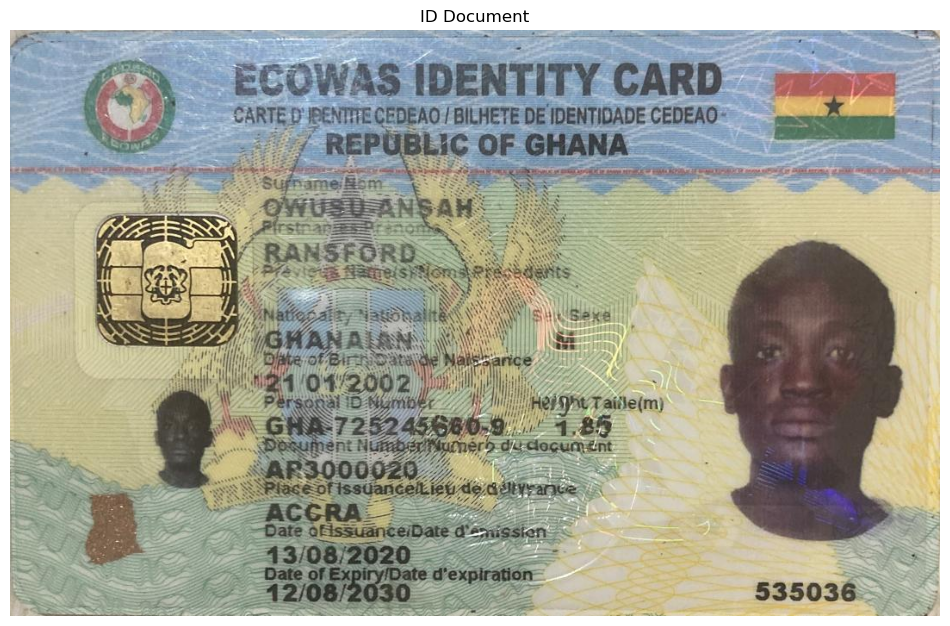

In [4]:
if img is not None:
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('ID Document')
    plt.show()


In [5]:
result = ocr.predict(img)
result

[{'input_path': None,
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[179, ..., 194],
           ...,
           [177, ..., 206]],
   
          ...,
   
          [[151, ..., 178],
           ...,
           [178, ..., 210]]], shape=(681, 1080, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': True},
   'angle': 0,
   'rot_img': array([[[179, ..., 194],
           ...,
           [177, ..., 206]],
   
          ...,
   
          [[151, ..., 178],
           ...,
           [178, ..., 210]]], shape=(681, 1080, 3), dtype=uint8),
   'output_img': array([[[160, ..., 143],
           ...,
           [198, ..., 170]],
   
          ...,
   
          [[167, ..., 173],
           ...,
           [153, ..., 161]]], shape=(681, 1080, 3), dtype=uint8)},
  'dt_polys': [array([[161,   0],
          ...,
          [161,  42]], shape=(4, 2), dtype=int16),
   array([[163,  47],


**Ghana Card Format**

In [46]:
import re
import numpy as np
from difflib import SequenceMatcher

def normalize(text):
    return re.sub(r'[^A-Z0-9]', '', text.upper())

def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def extract_ghana_card_data(ocr_result):
    data = ocr_result[0]
    texts = data["rec_texts"]
    boxes = data["dt_polys"]

    items = []
    for text, box in zip(texts, boxes):
        y = np.mean([p[1] for p in box])
        x = np.mean([p[0] for p in box])
        items.append({
            "text": text.strip(),
            "norm": normalize(text),
            "x": x,
            "y": y
        })

    # Ensure reading order
    items.sort(key=lambda i: (i["y"], i["x"]))

    result = {
        "Surname": "Not Found",
        "First_Names": "Not Found",
        "Full_Name": "Not Found",
        "Ghana_Card_Number": "Not Found",
        "Ghana_Card_Number_Source": None
    }

    surname_idx = None
    firstname_idx = None

    # -------- LABEL DETECTION --------
    for i, item in enumerate(items):
        t = item["norm"]

        if similar(t, "SURNAMENOM") > 0.75:
            surname_idx = i

        if similar(t, "FIRSTNAMESAPRENOMS") > 0.75:
            firstname_idx = i

    # -------- VALUE EXTRACTION --------
    def next_value(idx):
        if idx is not None and idx + 1 < len(items):
            return items[idx + 1]["text"]
        return None

    result["Surname"] = next_value(surname_idx) or result["Surname"]
    result["First_Names"] = next_value(firstname_idx) or result["First_Names"]

    if result["Surname"] != "Not Found" and result["First_Names"] != "Not Found":
        result["Full_Name"] = f"{result['Surname']} {result['First_Names']}"

    # -------- GHANA CARD NUMBER (AUTHORITATIVE REGEX) --------
    # Format: GHA-XXXXXXXXX-X
    for item in items:
        raw = item["text"].upper().replace(" ", "")
        match = re.search(r"GHA-\d{9}-\d", raw)
        if match:
            result["Ghana_Card_Number"] = match.group()
            result["Ghana_Card_Number_Source"] = "Regex"
            break

    return result



# Run it
extracted = extract_ghana_card_data(result)
print("--- Final Extraction ---")
for key, value in extracted.items():
    print(f"{key}: {value}")

--- Final Extraction ---
Surname: AIDOO
First_Names: ENOCK KWADWO
Full_Name: AIDOO ENOCK KWADWO
Ghana_Card_Number: GHA-723901326-3
Ghana_Card_Number_Source: Regex


**For Voters ID Format**

In [37]:
ocr = PaddleOCR(use_angle_cls=True, lang='en')
image_path = './photos/Voters_ID.jpeg'
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not read image from {image_path}")
    print("Please check if the file exists and the path is correct")
else:
    print(f"Image loaded successfully! Shape: {img.shape}")
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


C:\Users\Enoch\AppData\Local\Temp\ipykernel_9048\3728231389.py:1: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please d

Image loaded successfully! Shape: (695, 1080, 3)


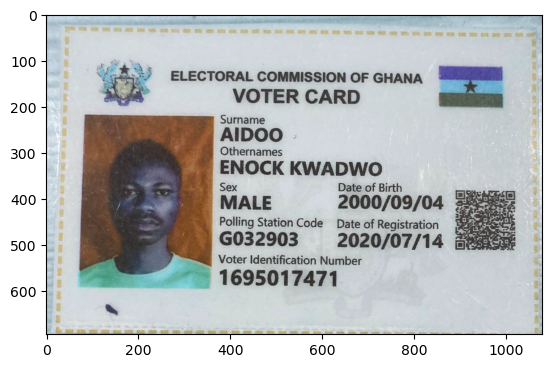

In [38]:
plt.figure()
plt.imshow(img)
plt.show()


In [39]:
result = ocr.predict(img)
result

[{'input_path': None,
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[198, ..., 224],
           ...,
           [108, ..., 140]],
   
          ...,
   
          [[182, ..., 211],
           ...,
           [183, ..., 211]]], shape=(695, 1080, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': True},
   'angle': 0,
   'rot_img': array([[[198, ..., 224],
           ...,
           [108, ..., 140]],
   
          ...,
   
          [[182, ..., 211],
           ...,
           [183, ..., 211]]], shape=(695, 1080, 3), dtype=uint8),
   'output_img': array([[[200, ..., 146],
           ...,
           [175, ..., 153]],
   
          ...,
   
          [[212, ..., 216],
           ...,
           [202, ..., 212]]], shape=(695, 1080, 3), dtype=uint8)},
  'dt_polys': [array([[235,  91],
          ...,
          [235, 121]], shape=(4, 2), dtype=int16),
   array([[379, 131],


In [41]:
import re
import numpy as np
from difflib import SequenceMatcher

def normalize(text):
    return re.sub(r'[^A-Z0-9]', '', text.upper())

def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def extract_voter_card_data(ocr_result):
    data = ocr_result[0]

    texts = data["rec_texts"]
    boxes = data["dt_polys"]

    items = []
    for text, box in zip(texts, boxes):
        y = np.mean([p[1] for p in box])
        x = np.mean([p[0] for p in box])
        items.append({
            "text": text.strip(),
            "norm": normalize(text),
            "x": x,
            "y": y
        })

    # Ensure reading order
    items.sort(key=lambda i: (i["y"], i["x"]))

    result = {
        "Surname": "Not Found",
        "Othernames": "Not Found",
        "Full_Name": "Not Found",
        "ID_Number": "Not Found",
        "ID_Number_Source": None
    }

    surname_idx = None
    othernames_idx = None
    id_idx = None

    # ---- LABEL DETECTION ----
    for i, item in enumerate(items):
        t = item["norm"]

        if similar(t, "SURNAME") > 0.8:
            surname_idx = i

        if similar(t, "OTHERNAMES") > 0.8:
            othernames_idx = i

        if (
            similar(t, "VOTERIDENTIFICATIONNUMBER") > 0.8 or
            similar(t, "VOTERIDNUMBER") > 0.8
        ):
            id_idx = i

    # ---- VALUE EXTRACTION ----
    def next_value(idx):
        if idx is not None and idx + 1 < len(items):
            return items[idx + 1]["text"]
        return None

    result["Surname"] = next_value(surname_idx) or result["Surname"]
    result["Othernames"] = next_value(othernames_idx) or result["Othernames"]

    if result["Surname"] != "Not Found" and result["Othernames"] != "Not Found":
        result["Full_Name"] = f"{result['Surname']} {result['Othernames']}"

    # ---- ID NUMBER EXTRACTION ----
    id_candidate = next_value(id_idx)
    if id_candidate:
        id_norm = normalize(id_candidate)
        if re.fullmatch(r"\d{8,12}", id_norm):
            result["ID_Number"] = id_norm
            result["ID_Number_Source"] = "Label"

    # ---- FALLBACK: REGEX SCAN ----
    if result["ID_Number"] == "Not Found":
        for item in items:
            if re.fullmatch(r"\d{8,12}", item["norm"]):
                result["ID_Number"] = item["norm"]
                result["ID_Number_Source"] = "Regex"
                break
                
    return result


# Execution
data = extract_voter_card_data(result)

print(f"✅ Surname: {data['Surname']}")
print(f"✅ Other Names: {data['Othernames']}")
print(f"✅ ID Number: {data['ID_Number']}")

✅ Surname: AIDOO
✅ Other Names: ENOCK KWADWO
✅ ID Number: 1695017471


**For Passport**

In [27]:
ocr = PaddleOCR(use_angle_cls=True, lang='en')
image_path = './photos/enoch_pass.jpg'
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not read image from {image_path}")
    print("Please check if the file exists and the path is correct")
else:
    print(f"Image loaded successfully! Shape: {img.shape}")
    # Convert BGR to RGB for matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


C:\Users\Enoch\AppData\Local\Temp\ipykernel_9048\2738247842.py:1: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang='en')
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please d

Image loaded successfully! Shape: (497, 720, 3)


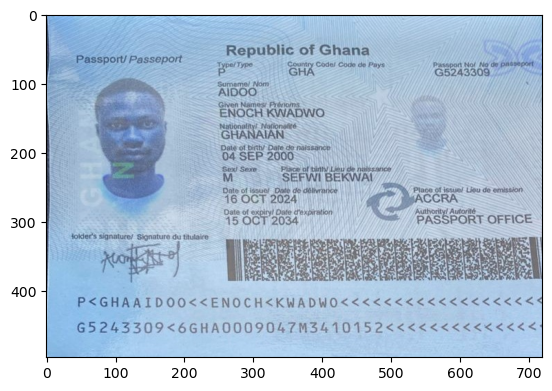

In [28]:
plt.figure()
plt.imshow(img)
plt.show()


In [29]:
result = ocr.predict(img)
result

[{'input_path': None,
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[ 91, ..., 166],
           ...,
           [184, ..., 247]],
   
          ...,
   
          [[ 90, ..., 161],
           ...,
           [171, ..., 238]]], shape=(497, 720, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': True},
   'angle': 0,
   'rot_img': array([[[ 91, ..., 166],
           ...,
           [184, ..., 247]],
   
          ...,
   
          [[ 90, ..., 161],
           ...,
           [171, ..., 238]]], shape=(497, 720, 3), dtype=uint8),
   'output_img': array([[[139, ..., 218],
           ...,
           [151, ..., 220]],
   
          ...,
   
          [[137, ..., 229],
           ...,
           [181, ..., 238]]], shape=(497, 720, 3), dtype=uint8)},
  'dt_polys': [array([[262,   6],
          ...,
          [262,  32]], shape=(4, 2), dtype=int16),
   array([[31, 29],
     

In [ ]:
import re
import numpy as np
from difflib import SequenceMatcher

def normalize(text):
    return re.sub(r'[^A-Z0-9<]', '', text.upper())

def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()


In [36]:
import re
import numpy as np
from difflib import SequenceMatcher

def normalize(text):
    return re.sub(r'[^A-Z0-9<]', '', text.upper())

def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

def extract_ghana_passport_data(ocr_result):
    data = ocr_result[0]
    boxes = data['dt_polys']
    texts = data['rec_texts']

    items = []
    for text, box in zip(texts, boxes):
        y = np.mean([p[1] for p in box])
        x = np.mean([p[0] for p in box])
        items.append({
            "text": text.strip(),
            "norm": normalize(text),
            "x": x,
            "y": y
        })

    # Sort in reading order
    items.sort(key=lambda i: (i["y"], i["x"]))

    info = {
        "Surname": "Not Found",
        "Given_Names": "Not Found",
        "Passport_Number": "Not Found",
        "Passport_Number_Source": None
    }

    surname_idx = None
    given_idx = None
    passport_label_idx = None

    # -------- VIZ SCAN --------
    for i, item in enumerate(items):
        t = item["norm"]

        if similar(t, "SURNAMENOM") > 0.7:
            surname_idx = i

        if similar(t, "GIVENNAMESPRENOMS") > 0.7:
            given_idx = i

        if similar(t, "PASSPORTNO") > 0.7:
            passport_label_idx = i

    if surname_idx is not None and surname_idx + 1 < len(items):
        info["Surname"] = items[surname_idx + 1]["text"]

    if given_idx is not None and given_idx + 1 < len(items):
        info["Given_Names"] = items[given_idx + 1]["text"]

    if passport_label_idx is not None and passport_label_idx + 1 < len(items):
        candidate = items[passport_label_idx + 1]["norm"]
        if re.match(r"G[0-9]{6,8}", candidate):
            info["Passport_Number"] = candidate
            info["Passport_Number_Source"] = "VIZ"

    # -------- MRZ SCAN (AUTHORITATIVE) --------
    mrz_candidates = [
        i["norm"] for i in items
        if len(i["norm"]) >= 30 and i["norm"].count("<") >= 5
    ]

    if len(mrz_candidates) >= 2:
        mrz_line_2 = mrz_candidates[-1]

        passport_no = mrz_line_2[:9].replace("<", "")
        passport_no = passport_no.replace("O", "0").replace("I", "1")

        if re.match(r"G[0-9]{6,8}", passport_no):
            info["Passport_Number"] = passport_no
            info["Passport_Number_Source"] = "MRZ"

    return info



# Run it
extracted = extract_ghana_passport_data(result)
print("--- Final Extraction ---")
for key, value in extracted.items():
    print(f"{key}: {value}")


--- Final Extraction ---
Surname: AIDOO
Given_Names: ENOCH KWADWO
Passport_Number: G5243309
Passport_Number_Source: MRZ


**PUT TOGETHER**

In [1]:
"""
ID Card OCR Module
Extracts names and ID numbers from Ghana Card, Voter's ID, and Passport using PaddleOCR
"""
import os
os.environ["FLAGS_enable_mkldnn"] = "0"
os.environ["FLAGS_use_pir_api"] = "0"


from paddleocr import PaddleOCR
import cv2
import re
import numpy as np
from typing import Dict, Optional
from difflib import SequenceMatcher



class IDCardOCR:
    """
    A class for extracting information from ID cards using OCR.
    Supports Ghana Card and Voter's ID formats.
    """
    
    def __init__(self, use_angle_cls: bool = False, lang: str = 'en'):
        """
        Initialize the OCR engine.
        
        Args:
            use_angle_cls: Whether to use angle classification (default: False for stability)
            lang: Language for OCR (default: 'en')
        """
        self.ocr = PaddleOCR(use_angle_cls=use_angle_cls, lang=lang)
    
    def _normalize(self, text: str) -> str:
        """Normalize text by removing special characters and converting to uppercase."""
        return re.sub(r'[^A-Z0-9<]', '', text.upper())
    
    def _similar(self, a: str, b: str) -> float:
        """Calculate similarity ratio between two strings."""
        return SequenceMatcher(None, a, b).ratio()
    
    def read_image(self, image_path: str) -> Optional[np.ndarray]:
        """
        Read an image from the specified path.
        
        Args:
            image_path: Path to the image file
            
        Returns:
            Numpy array of the image or None if failed
        """
        img = cv2.imread(image_path)
        if img is None:
            print(f"Error: Could not read image from {image_path}")
            print("Please check if the file exists and the path is correct")
            return None
        print(f"Image loaded successfully! Shape: {img.shape}")
        return img
    
    def perform_ocr(self, image: np.ndarray) -> list:
        """
        Perform OCR on the given image.
        
        Args:
            image: Image as numpy array
            
        Returns:
            OCR result from PaddleOCR
        """
        return self.ocr.predict(image)
    
    def extract_ghana_card_data(self, ocr_result: list) -> Dict[str, str]:
        """
        Extract name and ID number from Ghana Card format using improved label matching.
        
        Args:
            ocr_result: OCR result from PaddleOCR
            
        Returns:
            Dictionary containing Surname, First_Names, Full_Name, and Ghana_Card_Number
        """
        data = ocr_result[0]
        texts = data["rec_texts"]
        boxes = data["dt_polys"]

        # Build items with normalized text and positions
        items = []
        for text, box in zip(texts, boxes):
            y = np.mean([p[1] for p in box])
            x = np.mean([p[0] for p in box])
            items.append({
                "text": text.strip(),
                "norm": self._normalize(text),
                "x": x,
                "y": y
            })

        # Ensure reading order (top to bottom, left to right)
        items.sort(key=lambda i: (i["y"], i["x"]))

        result = {
            "Surname": "Not Found",
            "First_Names": "Not Found",
            "Full_Name": "Not Found",
            "Ghana_Card_Number": "Not Found",
            "Ghana_Card_Number_Source": None
        }

        surname_idx = None
        firstname_idx = None

        # -------- LABEL DETECTION with fuzzy matching --------
        for i, item in enumerate(items):
            t = item["norm"]

            if self._similar(t, "SURNAMENOM") > 0.75:
                surname_idx = i

            if self._similar(t, "FIRSTNAMESAPRENOMS") > 0.75:
                firstname_idx = i

        # -------- VALUE EXTRACTION --------
        def next_value(idx):
            if idx is not None and idx + 1 < len(items):
                return items[idx + 1]["text"]
            return None

        result["Surname"] = next_value(surname_idx) or result["Surname"]
        result["First_Names"] = next_value(firstname_idx) or result["First_Names"]

        if result["Surname"] != "Not Found" and result["First_Names"] != "Not Found":
            result["Full_Name"] = f"{result['Surname']} {result['First_Names']}"

        # -------- GHANA CARD NUMBER (AUTHORITATIVE REGEX) --------
        # Format: GHA-XXXXXXXXX-X
        for item in items:
            raw = item["text"].upper().replace(" ", "")
            match = re.search(r"GHA-\d{9}-\d", raw)
            if match:
                result["Ghana_Card_Number"] = match.group()
                result["Ghana_Card_Number_Source"] = "Regex"
                break

        return result
    
    def extract_voters_id_data(self, ocr_result: list) -> Dict[str, str]:
        """
        Extract name and ID number from Voter's ID format using improved label matching.
        
        Args:
            ocr_result: OCR result from PaddleOCR
            
        Returns:
            Dictionary containing Surname, Othernames, Full_Name, and ID_Number
        """
        data = ocr_result[0]
        texts = data["rec_texts"]
        boxes = data["dt_polys"]

        items = []
        for text, box in zip(texts, boxes):
            y = np.mean([p[1] for p in box])
            x = np.mean([p[0] for p in box])
            items.append({
                "text": text.strip(),
                "norm": self._normalize(text),
                "x": x,
                "y": y
            })

        # Ensure reading order
        items.sort(key=lambda i: (i["y"], i["x"]))

        result = {
            "Surname": "Not Found",
            "Othernames": "Not Found",
            "Full_Name": "Not Found",
            "ID_Number": "Not Found",
            "ID_Number_Source": None
        }

        surname_idx = None
        othernames_idx = None
        id_idx = None

        # ---- LABEL DETECTION with fuzzy matching ----
        for i, item in enumerate(items):
            t = item["norm"]

            if self._similar(t, "SURNAME") > 0.8:
                surname_idx = i

            if self._similar(t, "OTHERNAMES") > 0.8:
                othernames_idx = i

            if (
                self._similar(t, "VOTERIDENTIFICATIONNUMBER") > 0.8 or
                self._similar(t, "VOTERIDNUMBER") > 0.8
            ):
                id_idx = i

        # ---- VALUE EXTRACTION ----
        def next_value(idx):
            if idx is not None and idx + 1 < len(items):
                return items[idx + 1]["text"]
            return None

        result["Surname"] = next_value(surname_idx) or result["Surname"]
        result["Othernames"] = next_value(othernames_idx) or result["Othernames"]

        if result["Surname"] != "Not Found" and result["Othernames"] != "Not Found":
            result["Full_Name"] = f"{result['Surname']} {result['Othernames']}"

        # ---- ID NUMBER EXTRACTION ----
        id_candidate = next_value(id_idx)
        if id_candidate:
            id_norm = self._normalize(id_candidate)
            if re.fullmatch(r"\d{8,12}", id_norm):
                result["ID_Number"] = id_norm
                result["ID_Number_Source"] = "Label"

        # ---- FALLBACK: REGEX SCAN ----
        if result["ID_Number"] == "Not Found":
            for item in items:
                if re.fullmatch(r"\d{8,12}", item["norm"]):
                    result["ID_Number"] = item["norm"]
                    result["ID_Number_Source"] = "Regex"
                    break

        return result
    
    def extract_passport_data(self, ocr_result: list) -> Dict[str, str]:
        """
        Extract information from Ghana Passport using improved label matching and MRZ.
        
        Args:
            ocr_result: OCR result from PaddleOCR
            
        Returns:
            Dictionary containing Surname, Given_Names, and Passport_Number
        """
        data = ocr_result[0]
        boxes = data['dt_polys']
        texts = data['rec_texts']

        items = []
        for text, box in zip(texts, boxes):
            y = np.mean([p[1] for p in box])
            x = np.mean([p[0] for p in box])
            items.append({
                "text": text.strip(),
                "norm": self._normalize(text),
                "x": x,
                "y": y
            })

        # Sort in reading order
        items.sort(key=lambda i: (i["y"], i["x"]))

        info = {
            "Surname": "Not Found",
            "Given_Names": "Not Found",
            "Passport_Number": "Not Found",
            "Passport_Number_Source": None
        }

        surname_idx = None
        given_idx = None
        passport_label_idx = None

        # -------- LABEL DETECTION --------
        for i, item in enumerate(items):
            t = item["norm"]

            if self._similar(t, "SURNAMENOM") > 0.7:
                surname_idx = i

            if self._similar(t, "GIVENNAMESPRENOMS") > 0.7:
                given_idx = i

            if self._similar(t, "PASSPORTNO") > 0.7:
                passport_label_idx = i

        # -------- VALUE EXTRACTION --------
        if surname_idx is not None and surname_idx + 1 < len(items):
            info["Surname"] = items[surname_idx + 1]["text"]

        if given_idx is not None and given_idx + 1 < len(items):
            info["Given_Names"] = items[given_idx + 1]["text"]

        if passport_label_idx is not None and passport_label_idx + 1 < len(items):
            candidate = items[passport_label_idx + 1]["norm"]
            if re.match(r"G[0-9]{6,8}", candidate):
                info["Passport_Number"] = candidate
                info["Passport_Number_Source"] = "Label"

        # -------- MRZ SCAN (AUTHORITATIVE) --------
        mrz_candidates = [
            i["norm"] for i in items
            if len(i["norm"]) >= 30 and i["norm"].count("<") >= 5
        ]

        if len(mrz_candidates) >= 2:
            mrz_line_2 = mrz_candidates[-1]

            passport_no = mrz_line_2[:9].replace("<", "")
            passport_no = passport_no.replace("O", "0").replace("I", "1")

            if re.match(r"G[0-9]{6,8}", passport_no):
                info["Passport_Number"] = passport_no
                info["Passport_Number_Source"] = "MRZ"

        return info
    
    def process_ghana_card(self, image_path: str) -> Optional[Dict[str, str]]:
        """
        Process a Ghana Card image and extract information.
        
        Args:
            image_path: Path to the Ghana Card image
            
        Returns:
            Dictionary with extracted data or None if failed
        """
        img = self.read_image(image_path)
        if img is None:
            return None
        
        ocr_result = self.perform_ocr(img)
        return self.extract_ghana_card_data(ocr_result)
    
    def process_voters_id(self, image_path: str) -> Optional[Dict[str, str]]:
        """
        Process a Voter's ID image and extract information.
        
        Args:
            image_path: Path to the Voter's ID image
            
        Returns:
            Dictionary with extracted data or None if failed
        """
        img = self.read_image(image_path)
        if img is None:
            return None
        
        ocr_result = self.perform_ocr(img)
        return self.extract_voters_id_data(ocr_result)
    
    def process_passport(self, image_path: str) -> Optional[Dict[str, str]]:
        """
        Process a Passport image and extract information.
        
        Args:
            image_path: Path to the Passport image
            
        Returns:
            Dictionary with extracted data or None if failed
        """
        img = self.read_image(image_path)
        if img is None:
            return None
        
        ocr_result = self.perform_ocr(img)
        return self.extract_passport_data(ocr_result)
    
    def process_id_card(self, image_path: str, card_type: str = 'auto') -> Optional[Dict[str, str]]:
        """
        Process an ID card and automatically detect or use specified type.
        Supports: Ghana Card, Voter's ID, and Passport formats
        
        Args:
            image_path: Path to the ID card image
            card_type: Type of card ('ghana_card', 'voters_id', 'passport', or 'auto')
            
        Returns:
            Dictionary with extracted data or None if failed
        """
        img = self.read_image(image_path)
        if img is None:
            return None
        
        ocr_result = self.perform_ocr(img)
        
        if card_type == 'ghana_card':
            return self.extract_ghana_card_data(ocr_result)
        elif card_type == 'voters_id':
            return self.extract_voters_id_data(ocr_result)
        elif card_type == 'passport':
            return self.extract_passport_data(ocr_result)
        else:
            # Auto-detect based on content
            texts = ocr_result[0]['rec_texts']
            all_text = ' '.join(texts).upper()
            
            if 'GHA-' in all_text or 'GHANA CARD' in all_text:
                return self.extract_ghana_card_data(ocr_result)
            elif 'VOTER IDENTIFICATION' in all_text or 'ELECTORAL' in all_text:
                return self.extract_voters_id_data(ocr_result)
            elif 'PASSPORT' in all_text or 'MRZ' in all_text:
                return self.extract_passport_data(ocr_result)
            else:
                # Default to Ghana Card extraction
                print("Warning: Could not determine card type. Attempting Ghana Card extraction.")
                return self.extract_ghana_card_data(ocr_result)


if __name__ == "__main__":
    # Example usage
    ocr_processor = IDCardOCR()
    
    # Process Ghana Card
    print("=== Processing Ghana Card ===")
    ghana_data = ocr_processor.process_ghana_card('./photos/IDFront.png')
    if ghana_data:
        print("--- Ghana Card Extraction ---")
        for key, value in ghana_data.items():
            print(f"{key}: {value}")
    
    print("\n" + "="*50 + "\n")
    
    # Process Voter's ID
    print("=== Processing Voter's ID ===")
    voters_data = ocr_processor.process_voters_id('./photos/Voters_ID.jpeg')
    if voters_data:
        print("--- Voter's ID Extraction ---")
        for key, value in voters_data.items():
            print(f"✅ {key}: {value}")
    
    print("\n" + "="*50 + "\n")
    
    # Process Passport
    print("=== Processing Passport ===")
    passport_data = ocr_processor.process_passport('./photos/enoch_pass.jpg')
    if passport_data:
        print("--- Passport Extraction ---")
        for key, value in passport_data.items():
            print(f"✅ {key}: {value}")


Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.
C:\Users\Enoch\AppData\Local\Temp\ipykernel_10572\3526441092.py:33: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  self.ocr = PaddleOCR(use_angle_cls=use_angle_cls, lang=lang)
C:\Users\Enoch\AppData\Roaming\Python\Python312\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Enoch\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', 

=== Processing Ghana Card ===
Image loaded successfully! Shape: (672, 1081, 3)


NotImplementedError: (Unimplemented) ConvertPirAttribute2RuntimeAttribute not support [pir::ArrayAttribute<pir::DoubleAttribute>]  (at ..\paddle\fluid\framework\new_executor\instruction\onednn\onednn_instruction.cc:118)
